# Pairs Trading & Statistical Arbitrage
## 02 - Cointegration Testing

This notebook formally tests whether Visa (V) and Mastercard (MA) are cointegrated using the Engle-Granger two-step method. If cointegration is confirmed, the spread between them is stationary and mean reverting, the statistical foundation that makes pairs trading viable.

### The Engle-Granger Two-Step Method

**Step 1 — Estimate the Hedge Ratio**
We regress MA prices on V prices using OLS to estimate the hedge ratio β. This tells us how much MA moves for every unit move in V. The hedge ratio is what scales the two series so their spread is comparable, without it we would be comparing raw prices which are on different scales.

**Step 2 — Test the Residuals for Stationarity**
The residuals from the regression represent the spread between the two series after accounting for their relative scaling. If the pair is cointegrated, these residuals should be stationary, fluctuating around zero with no trend and a tendency to revert. We test this formally using the Augmented Dickey-Fuller (ADF) test.

### The ADF Test
The ADF test tests the null hypothesis that a series has a unit root, meaning it is non-stationary and wanders randomly with no fixed mean. Rejecting the null gives us statistical evidence that the spread is stationary and therefore mean reverting. A p-value below 0.05 is our threshold for rejection.

### Why This Matters
Without formal cointegration testing, any apparent relationship between two trending series could be spurious, two independent random walks that happen to move together by chance. The Engle-Granger method gives us a statistically rigorous basis for the pairs trade rather than just visual intuition.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from statsmodels.tsa.stattools import adfuller

# Reload prices
tickers = ["V", "MA"]
raw = yf.download(tickers, start="2010-01-01", auto_adjust=True)["Close"]
prices = raw.dropna()

print(f"Loaded: {prices.shape[0]} days")
print(prices.tail())

[*********************100%***********************]  2 of 2 completed

Loaded: 4136 days
Ticker              MA           V
Date                              
2026-06-08  485.670013  319.670013
2026-06-09  495.239990  325.049988
2026-06-10  489.079987  322.959991
2026-06-11  486.510010  319.049988
2026-06-12  489.980011  322.390015


In [2]:
# Regress MA on V using OLS
# We add a constant so the regression is: MA = α + β*V + ε
X = add_constant(prices["V"])
y = prices["MA"]

model = OLS(y, X).fit()
print(model.summary())

# Extract hedge ratio
alpha = model.params["const"]
beta = model.params["V"]

print(f"\nHedge Ratio (β): {beta:.4f}")
print(f"Intercept (α):   {alpha:.4f}")
print(f"\nInterpretation: For every $1 move in V, MA moves ${beta:.4f} on average")

                            OLS Regression Results                            
Dep. Variable:                     MA   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                 7.368e+05
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:16:23   Log-Likelihood:                -16408.
No. Observations:                4136   AIC:                         3.282e+04
Df Residuals:                    4134   BIC:                         3.283e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -16.7086      0.336    -49.677      0.0

In [5]:
# Spread = MA - (α + β*V)
# These are the residuals from the regression
spread = prices["MA"] - (alpha + beta * prices["V"])

# Run ADF test on the spread
adf_result = adfuller(spread)

print("ADF Test Results:")
print(f"  Test Statistic:  {adf_result[0]:.4f}")
print(f"  P-value:         {adf_result[1]:.4f}")
print(f"  Critical Values:")
for key, val in adf_result[4].items():
    print(f"    {key}: {val:.4f}")

print("Conclusion: Reject null - spread is stationary")

ADF Test Results:
  Test Statistic:  -3.7072
  P-value:         0.0040
  Critical Values:
    1%: -3.4319
    5%: -2.8622
    10%: -2.5671
Conclusion: Reject null - spread is stationary


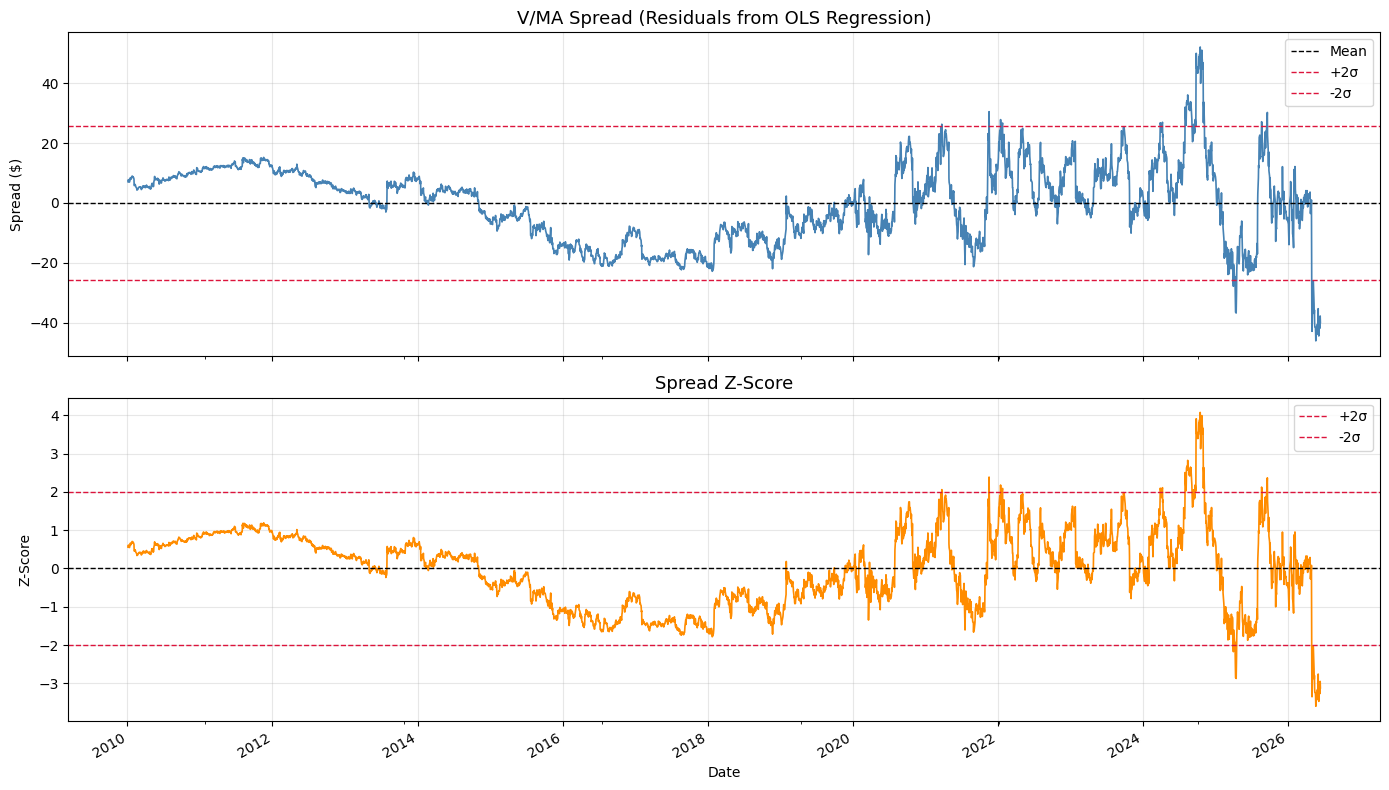

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Spread over time
spread.plot(ax=ax1, color="steelblue", linewidth=1.2)
ax1.axhline(spread.mean(), color="black", linewidth=1, linestyle="--", label="Mean")
ax1.axhline(spread.mean() + 2*spread.std(), color="crimson", linewidth=1, linestyle="--", label="+2σ")
ax1.axhline(spread.mean() - 2*spread.std(), color="crimson", linewidth=1, linestyle="--", label="-2σ")
ax1.set_title("V/MA Spread (Residuals from OLS Regression)", fontsize=13)
ax1.set_ylabel("Spread ($)")
ax1.legend()
ax1.grid(alpha=0.3)

# Z-score of spread
zscore = (spread - spread.mean()) / spread.std()
zscore.plot(ax=ax2, color="darkorange", linewidth=1.2)
ax2.axhline(0, color="black", linewidth=1, linestyle="--")
ax2.axhline(2, color="crimson", linewidth=1, linestyle="--", label="+2σ")
ax2.axhline(-2, color="crimson", linewidth=1, linestyle="--", label="-2σ")
ax2.set_title("Spread Z-Score", fontsize=13)
ax2.set_ylabel("Z-Score")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()